In [1]:
# Course 1

In [27]:
# Librairies 
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
#Load the data
df = pd.read_csv('Python - Time Series Forecasting/Time Series Analysis/Introduction to Time Series Forecasting/bitcoin_price.csv', index_col = "Date", parse_dates=True)
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [7]:
df.index

DatetimeIndex(['2014-09-17', '2014-09-18', '2014-09-19', '2014-09-20',
               '2014-09-21', '2014-09-22', '2014-09-23', '2014-09-24',
               '2014-09-25', '2014-09-26',
               ...
               '2023-12-21', '2023-12-22', '2023-12-23', '2023-12-24',
               '2023-12-25', '2023-12-26', '2023-12-27', '2023-12-28',
               '2023-12-29', '2023-12-30'],
              dtype='datetime64[ns]', name='Date', length=3392, freq=None)

In [10]:
# Resempling to Monthly frequency and calculate the mean clothing price 
df.resample("W").mean()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-21,429.916998,437.718195,406.624402,416.859003,416.859003,3.138068e+07
2014-09-28,410.650718,418.668993,399.377141,407.692566,407.692566,2.668180e+07
2014-10-05,369.774288,376.721000,353.207140,361.426570,361.426570,3.952256e+07
2014-10-12,346.927429,363.308864,337.567858,355.234580,355.234580,4.873611e+07
2014-10-19,389.010284,397.790427,380.410575,390.479854,390.479854,2.241458e+07
...,...,...,...,...,...,...
2023-12-03,38038.414062,38743.479353,37766.444196,38399.994978,38399.994978,1.919430e+10
2023-12-10,43002.227121,44027.167411,42586.383929,43538.877232,43538.877232,2.692909e+10
2023-12-17,42369.368862,42969.940848,41148.103237,42020.472656,42020.472656,2.407050e+10


## Exploring Data 

In [21]:
# 7- Day rolling average of the closing price
df["7_day_rolling"] = df["Close"].rolling(window=7).mean()
df[['Close','7_day_rolling']]

,Close,7_day_rolling
Date,,
2014-09-17,457.334015,NaN
2014-09-18,424.440002,NaN
2014-09-19,394.795990,NaN
2014-09-20,408.903992,NaN
2014-09-21,398.821014,NaN
...,...,...
2023-12-26,42520.402344,43486.929688
2023-12-27,43442.855469,43457.016183
2023-12-28,42627.855469,43279.688058


<Axes: xlabel='Date'>

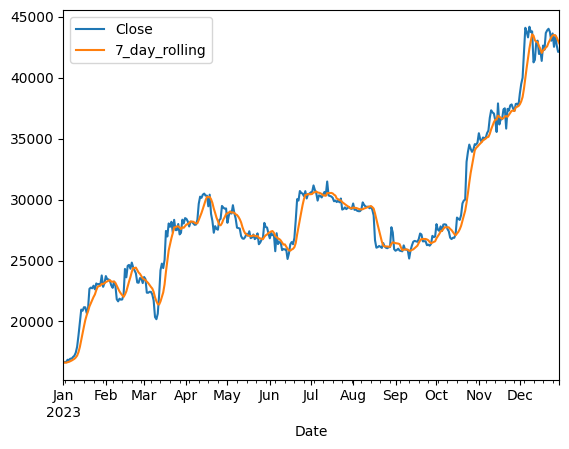

In [26]:
df[['Close','7_day_rolling']].loc['2023'].plot()

In [28]:
# Find out the highest average month

In [31]:
df.resample('ME').mean()['Close'].idxmax()

Timestamp('2021-11-30 00:00:00')

In [39]:
# Calculate Daily Returns
df['daily_returns'] = df['Close'].pct_change()*100

In [42]:
#Days with more than 20% of volatility
volatility = df[df['daily_returns'] < -15]
volatility

,Open,High,Low,Close,Adj Close,Volume,7_day_rolling,daily_returns
Date,,,,,,,,
2015-01-13,267.394012,268.277008,219.906006,225.860992,225.860992,72843904,271.743853,-15.659308
2015-01-14,223.893997,223.893997,171.509995,178.102997,178.102997,97638704,255.138994,-21.144862
2015-08-18,257.925995,257.993011,211.078995,211.078995,211.078995,42147200,255.035568,-18.178829
2016-01-15,430.255005,430.255005,364.330994,364.330994,364.330994,153351008,429.532571,-15.332114
2017-09-14,3875.370117,3920.600098,3153.860107,3154.949951,3154.949951,2716310016,3986.767160,-18.741101
2018-01-16,13836.099609,13843.099609,10194.900391,11490.500000,11490.500000,18853799936,13686.028460,-16.854801
2018-02-05,8270.540039,8364.839844,6756.680176,6955.270020,6955.270020,9285289984,8962.268485,-15.968807
2020-03-12,7913.616211,7929.116211,4860.354004,4970.788086,4970.788086,53980357243,7836.601214,-37.169539
2022-06-13,26737.578125,26795.589844,22141.257812,22487.388672,22487.388672,68204556440,28310.926339,-15.974726
